# Data Sourcing, EDA & Data Cleaning

**Agenda**
1. Understand data sources and EDA basics
2. Work with public and private datasets
3. Collect and explore data for analysis
4. Identify and handle missing values
5. Fix data types, rows, and columns
6. Handle outliers and standardize values


## 1. What is EDA?

**Exploratory Data Analysis (EDA)** is the process of examining a dataset before doing any modeling — to understand its structure, spot patterns, and catch problems early.


EDA steps:
- Look at the shape and structure (rows, columns, data types)
- Check summary statistics (mean, median, min, max)
- Visualize distributions (histograms, box plots)
- Look for missing values, duplicates, and outliers


## 2. Public vs Private Datasets

| Public Datasets | Private Datasets |
|---|---|
| Freely available (government portals) | Owned by a company/organization |
| Often need heavy cleaning | Usually more structured |
| No access restrictions | Confidentiality / access restrictions |
| Great for learning & practice | Used for real business decisions |



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("customer_data.csv")
df.head()

,CustomerID,Age,Gender,Country,PurchaseAmount,SignupDate,Rating
0,1001,56.0,F,United States,-3.86,01-01-2023,5.0
1,1002,46.0,male,U.K.,218.56,04-01-2023,4.0
2,1003,32.0,NaN,U.S.A,36.20,07-01-2023,3.0
3,1004,60.0,Male,U.S.A,185.95,10-01-2023,5.0
4,1005,25.0,female,U.K.,139.92,13-01-2023,NaN


## 3. Collecting & Exploring the Data
- How many rows and columns are there?
- What data type is each column?
- Are there any obvious issues at first glance?


In [3]:
# Shape of the dataset
print("Rows, Columns:", df.shape)

Rows, Columns: (206, 7)


In [4]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      206 non-null    int64  
 1   Age             191 non-null    float64
 2   Gender          190 non-null    object 
 3   Country         206 non-null    object 
 4   PurchaseAmount  191 non-null    float64
 5   SignupDate      206 non-null    object 
 6   Rating          190 non-null    float64
dtypes: float64(3), int64(1), object(3)
memory usage: 11.4+ KB


In [5]:
# Summary statistics for numeric columns
df.describe()

,CustomerID,Age,PurchaseAmount,Rating
count,206.000000,191.000000,191.000000,190.000000
mean,1100.592233,41.434555,247.067330,2.984211
std,58.144049,13.802923,603.864394,1.419726
min,1001.000000,18.000000,-58.690000,1.000000
25%,1050.250000,29.500000,112.525000,2.000000
50%,1100.500000,42.000000,160.690000,3.000000
75%,1150.750000,54.000000,196.990000,4.000000
max,1200.000000,64.000000,5380.800000,5.000000


In [6]:
# Quick look at categorical columns
print(df["Gender"].value_counts(dropna=False))
print()
print(df["Country"].value_counts(dropna=False))

Gender
Male      42
M         35
F         33
Female    32
male      25
female    23
NaN       16
Name: count, dtype: int64

Country
india             30
United States     27
U.K.              27
USA               26
India             24
Canada            22
U.S.A             17
UK                17
United Kingdom    16
Name: count, dtype: int64


### Issues spotted during exploration

- `Gender` has inconsistent labels: `Male`, `male`, `M`, `Female`, `female`, `F`
- `Country` has inconsistent labels: `USA`, `U.S.A`, `United States`, etc.
- There may be missing values in several columns



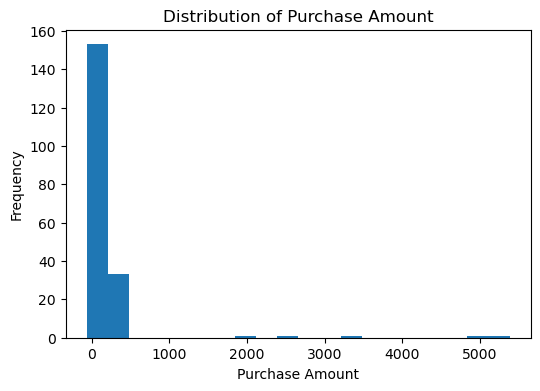

In [7]:
# Visualize the distribution of PurchaseAmount
plt.figure(figsize=(6,4))
plt.hist(df["PurchaseAmount"].dropna(), bins=20)
plt.title("Distribution of Purchase Amount")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.show()

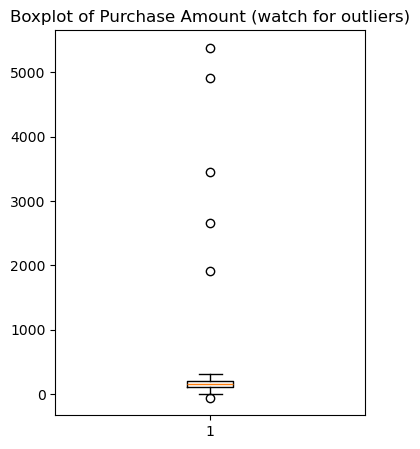

In [8]:
# Boxplot to visually spot outliers
plt.figure(figsize=(4,5))
plt.boxplot(df["PurchaseAmount"].dropna())
plt.title("Boxplot of Purchase Amount (watch for outliers)")
plt.show()

## 4. Identifying & Handling Missing Values


In [9]:
# Check missing values per column
df.isnull().sum()

CustomerID         0
Age               15
Gender            16
Country            0
PurchaseAmount    15
SignupDate         0
Rating            16
dtype: int64

In [3]:
df.isnull().sum()

CustomerID         0
Age               15
Gender            16
Country            0
PurchaseAmount    15
SignupDate         0
Rating            16
dtype: int64

In [10]:
# Fill numeric columns with median (robust to outliers)
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")  # forces text like '45.0' -> 45.0, invalid -> NaN
df["Age"] = df["Age"].fillna(df["Age"].median()) 

df["PurchaseAmount"] = df["PurchaseAmount"].fillna(df["PurchaseAmount"].median())
df["Rating"] = df["Rating"].fillna(df["Rating"].median())

# Fill categorical column with mode (most frequent value)
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

df.isnull().sum()

CustomerID        0
Age               0
Gender            0
Country           0
PurchaseAmount    0
SignupDate        0
Rating            0
dtype: int64

## 5. Fixing Data Types, Rows & Columns

Things to check:
- Are dates stored as proper datetime objects?
- Are there duplicate rows to remove?
- Are column names clean and consistent?


In [11]:
# Convert SignupDate to a proper datetime type
df["SignupDate"] = pd.to_datetime(df["SignupDate"], format="%d-%m-%Y")
print(df["SignupDate"].dtype)

datetime64[ns]


In [12]:
# Find and remove duplicate rows
print("Duplicate rows found:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Duplicate rows found: 6
Shape after removing duplicates: (200, 7)


## 6. Handling Outliers & Standardizing Values

**Outliers** — use the IQR (Interquartile Range) method:
- Anything below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` is considered an outlier

**Standardizing** — mapping inconsistent text values to one consistent label
(e.g. "USA", "U.S.A", "United States" → "USA")


In [13]:
# Detect outliers in purchaseamount using IQR
Q1 = df["PurchaseAmount"].quantile(0.25)
Q3 = df["PurchaseAmount"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["PurchaseAmount"] < lower) | (df["PurchaseAmount"] > upper)]
print("Outliers found:", len(outliers))
outliers[["CustomerID", "PurchaseAmount"]]

Outliers found: 10


,CustomerID,PurchaseAmount
0,1001,-3.86
19,1020,4907.00
60,1061,-58.69
65,1066,302.36
90,1091,3450.80
99,1100,1905.40
113,1114,2655.40
146,1147,304.40
169,1170,307.00
185,1186,5380.80


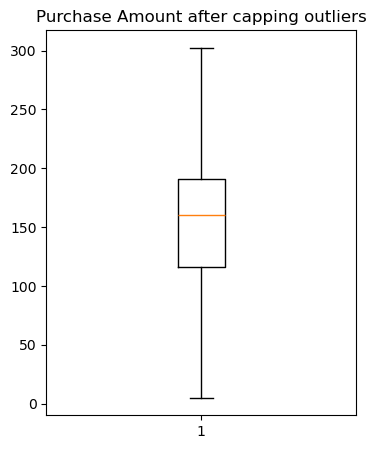

In [14]:
# Cap outliers instead of deleting them (keeps the row, limits extreme influence)
df["PurchaseAmount"] = df["PurchaseAmount"].clip(lower=lower, upper=upper)

plt.figure(figsize=(4,5))
plt.boxplot(df["PurchaseAmount"])
plt.title("Purchase Amount after capping outliers")
plt.show()

In [42]:
gender_map = {
    "male": "Male", "m": "Male",
    "female": "Female" , "f": "Female"
}

# Clean whitespace, lowercase for exact dictionary matching, replace, then capitalize standard names
df["Gender"] = df["Gender"].str.strip().str.lower().replace(gender_map).str.capitalize()
df["Gender"].value_counts()

Gender
Male      113
Female     87
Name: count, dtype: int64

In [40]:
# Standardize inconsistent Country values
country_map = {
    "usa": "USA", "u.s.a": "USA", "u.s.a.": "USA", "united states": "USA",
    "uk": "UK", "u.k.": "UK", "united kingdom": "UK",
    "india": "India", "canada": "Canada"
}

df["Country"] = df["Country"].str.strip().str.lower().replace(country_map).str.upper()
df["Country"].value_counts()

Country
USA       69
UK        59
INDIA     51
CANADA    21
Name: count, dtype: int64

## Final Check — Clean Dataset

In [41]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   CustomerID      200 non-null    int64         
 1   Age             200 non-null    float64       
 2   Gender          200 non-null    object        
 3   Country         200 non-null    object        
 4   PurchaseAmount  200 non-null    float64       
 5   SignupDate      200 non-null    datetime64[ns]
 6   Rating          200 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(2)
memory usage: 12.5+ KB


,CustomerID,Age,Gender,Country,PurchaseAmount,SignupDate,Rating
0,1001,56.0,Female,USA,5.03875,2023-01-01,5.0
1,1002,46.0,Male,UK,218.56000,2023-01-04,4.0
2,1003,32.0,Male,USA,36.20000,2023-01-07,3.0
3,1004,60.0,Male,USA,185.95000,2023-01-10,5.0
4,1005,25.0,Female,UK,139.92000,2023-01-13,3.0


In [157]:
# Save the cleaned dataset so it can be used in the next part (Univariate Analysis)
df.to_csv("customer_data_cleaned.csv", index=False)
print("Saved cleaned dataset as customer_data_cleaned.csv")

Saved cleaned dataset as customer_data_cleaned.csv


## Summary

- Explored a raw customer dataset: shape, types, distributions, and value counts
- Found issues: missing values, inconsistent categories, mixed data types, outliers
- Cleaned the dataset: filled missing values, fixed types, removed duplicates, capped outliers, standardized categories
- Saved the clean dataset 

